# BeatSense — ECG Heartbeat Classification

Мультиклассовая классификация сердечных сокращений по сигналам ECG (MIT-BIH).

**Классы:**
- 0 — Normal beat
- 1 — Supraventricular ectopic beat
- 2 — Ventricular ectopic beat
- 3 — Fusion beat
- 4 — Unknown beat

**Целевые метрики (из PRD):** Accuracy ≥ 85%, F1 ≥ 0.80.

**Датасет:** [ECG Heartbeat Categorization Dataset](https://www.kaggle.com/datasets/shayanfazeli/heartbeat).

## 1. Import Libraries

In [1]:
import os
import random
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from imblearn.over_sampling import SMOTE

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device: cpu
PyTorch: 2.12.0+cpu


## 2. Data Loading

Согласно `Data_Spec.md` raw-файлы лежат в `data/raw/`. Каждая строка CSV — один heartbeat: 187 значений сигнала + 1 колонка с меткой класса.

In [2]:
DATA_DIR = Path('../data/raw')
TRAIN_CSV = DATA_DIR / 'mitbih_train.csv'
TEST_CSV = DATA_DIR / 'mitbih_test.csv'

train_df = pd.read_csv(TRAIN_CSV, header=None)
test_df = pd.read_csv(TEST_CSV, header=None)

print(f'Train shape: {train_df.shape}')
print(f'Test shape:  {test_df.shape}')
train_df.head()

Train shape: (87554, 188)
Test shape:  (21892, 188)


,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
SIGNAL_LEN = 187
NUM_CLASSES = 5
CLASS_NAMES = {
    0: 'Normal',
    1: 'Supraventricular',
    2: 'Ventricular',
    3: 'Fusion',
    4: 'Unknown',
}

X_train_raw = train_df.iloc[:, :SIGNAL_LEN].values.astype(np.float32)
y_train_raw = train_df.iloc[:, SIGNAL_LEN].values.astype(np.int64)

X_test = test_df.iloc[:, :SIGNAL_LEN].values.astype(np.float32)
y_test = test_df.iloc[:, SIGNAL_LEN].values.astype(np.int64)

print(f'X_train_raw: {X_train_raw.shape}, y_train_raw: {y_train_raw.shape}')
print(f'X_test:      {X_test.shape}, y_test:      {y_test.shape}')

X_train_raw: (87554, 187), y_train_raw: (87554,)
X_test:      (21892, 187), y_test:      (21892,)


## 3. EDA — распределение классов и примеры сигналов

C:\Users\rusla\AppData\Local\Temp\ipykernel_18312\2522217544.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='viridis')


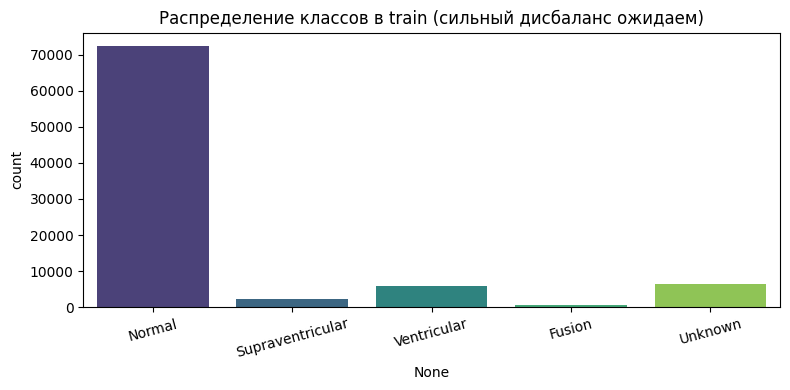

Normal              72471
Supraventricular     2223
Ventricular          5788
Fusion                641
Unknown              6431
Name: count, dtype: int64


In [4]:
counts = pd.Series(y_train_raw).value_counts().sort_index()
counts.index = [CLASS_NAMES[i] for i in counts.index]

plt.figure(figsize=(8, 4))
sns.barplot(x=counts.index, y=counts.values, palette='viridis')
plt.title('Распределение классов в train (сильный дисбаланс ожидаем)')
plt.ylabel('count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print(counts)

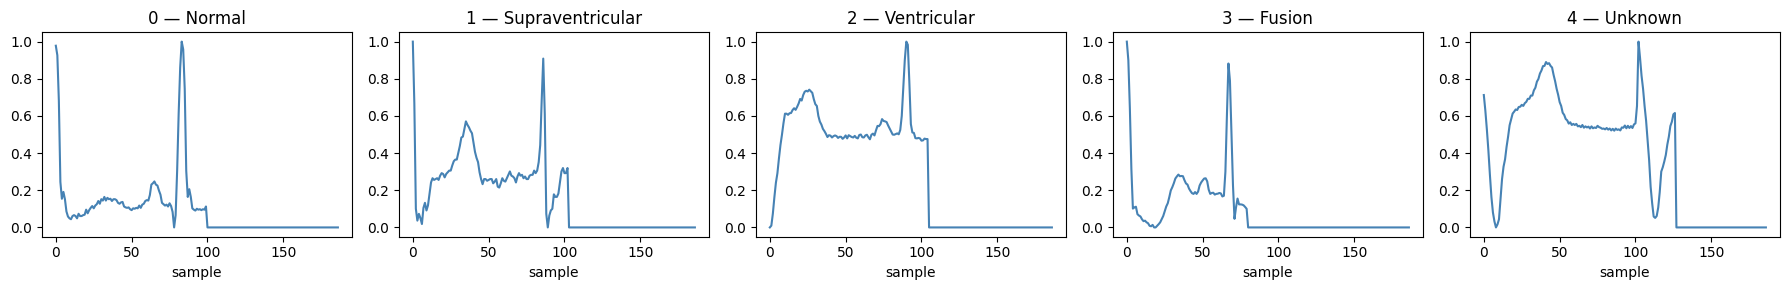

In [5]:
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(18, 3))
for cls in range(NUM_CLASSES):
    idx = np.where(y_train_raw == cls)[0][0]
    axes[cls].plot(X_train_raw[idx], color='steelblue')
    axes[cls].set_title(f'{cls} — {CLASS_NAMES[cls]}')
    axes[cls].set_xlabel('sample')
plt.tight_layout()
plt.show()

## 4. Preprocessing — масштабирование и балансировка

Сигналы датасета уже нормализованы в [0, 1], но в спецификации (`Data_Spec.md` §2) явно требуется применить MinMax — для устойчивости и совместимости с inference-pipeline применяем явно.

Класс 0 (Normal) доминирует — применяем **SMOTE** к train-выборке.

In [6]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test)

print(f'train min/max: {X_train_scaled.min():.3f} / {X_train_scaled.max():.3f}')

train min/max: 0.000 / 1.000


In [7]:
smote = SMOTE(random_state=SEED)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train_raw)

print(f'До  SMOTE: {np.bincount(y_train_raw)}')
print(f'После SMOTE: {np.bincount(y_train_bal)}')
print(f'Final train size: {X_train_bal.shape}')

До  SMOTE: [72471  2223  5788   641  6431]
После SMOTE: [72471 72471 72471 72471 72471]
Final train size: (362355, 187)


In [8]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_bal, y_train_bal,
    test_size=0.1,
    stratify=y_train_bal,
    random_state=SEED,
)
print(f'train: {X_tr.shape}, val: {X_val.shape}, test: {X_test_scaled.shape}')

train: (326119, 187), val: (36236, 187), test: (21892, 187)


## 5. PyTorch Dataset & DataLoader

In [9]:
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # (N, 1, 187)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 128

train_loader = DataLoader(ECGDataset(X_tr, y_tr), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(ECGDataset(X_val, y_val), batch_size=BATCH_SIZE)
test_loader = DataLoader(ECGDataset(X_test_scaled, y_test), batch_size=BATCH_SIZE)

xb, yb = next(iter(train_loader))
print(f'batch X: {xb.shape}, batch y: {yb.shape}')

batch X: torch.Size([128, 1, 187]), batch y: torch.Size([128])


## 6. Model Architecture — 1D CNN

Три блока Conv1D → BatchNorm → ReLU → MaxPool, затем GAP и полносвязный классификатор. Архитектура подобрана под длину 187 и компактные требования MVP (быстрый инференс ≤ 2–3 сек согласно `DoD.md`).

In [10]:
class ECGNet(nn.Module):
    def __init__(self, num_classes: int = 5):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(64)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(128)
        self.pool = nn.MaxPool1d(2)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(128, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.gap(x).squeeze(-1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)


model = ECGNet(NUM_CLASSES).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'Trainable params: {n_params:,}')

ECGNet(
  (conv1): Conv1d(1, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv2): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv3): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (gap): AdaptiveAvgPool1d(output_size=1)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=5, bias=True)
)
Trainable params: 44,229


## 7. Training

In [11]:
EPOCHS = 15
LR = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)


def run_epoch(loader, train_mode: bool):
    model.train(train_mode)
    total_loss, correct, total = 0.0, 0, 0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        with torch.set_grad_enabled(train_mode):
            logits = model(X)
            loss = criterion(logits, y)
            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
        total_loss += loss.item() * X.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += X.size(0)
    return total_loss / total, correct / total


history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
best_state = None

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train_mode=True)
    val_loss, val_acc = run_epoch(val_loader, train_mode=False)
    scheduler.step(val_loss)

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    print(f'Epoch {epoch:02d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | val loss {val_loss:.4f} acc {val_acc:.4f}')

model.load_state_dict(best_state)
print(f'\nBest val acc: {best_val_acc:.4f}')

Epoch 01 | train loss 0.2577 acc 0.9115 | val loss 0.2885 acc 0.9017
Epoch 02 | train loss 0.1304 acc 0.9553 | val loss 0.0988 acc 0.9670
Epoch 03 | train loss 0.0999 acc 0.9655 | val loss 0.1921 acc 0.9304
Epoch 04 | train loss 0.0817 acc 0.9722 | val loss 0.0816 acc 0.9705
Epoch 05 | train loss 0.0703 acc 0.9757 | val loss 0.1493 acc 0.9488
Epoch 06 | train loss 0.0619 acc 0.9787 | val loss 0.0791 acc 0.9720
Epoch 07 | train loss 0.0543 acc 0.9813 | val loss 0.0601 acc 0.9781
Epoch 08 | train loss 0.0505 acc 0.9824 | val loss 0.0532 acc 0.9816
Epoch 09 | train loss 0.0457 acc 0.9844 | val loss 0.0403 acc 0.9851
Epoch 10 | train loss 0.0421 acc 0.9857 | val loss 0.0454 acc 0.9839
Epoch 11 | train loss 0.0386 acc 0.9869 | val loss 0.0427 acc 0.9854
Epoch 12 | train loss 0.0364 acc 0.9873 | val loss 0.0531 acc 0.9806
Epoch 13 | train loss 0.0229 acc 0.9926 | val loss 0.0230 acc 0.9921
Epoch 14 | train loss 0.0207 acc 0.9930 | val loss 0.0218 acc 0.9921
Epoch 15 | train loss 0.0195 acc 0

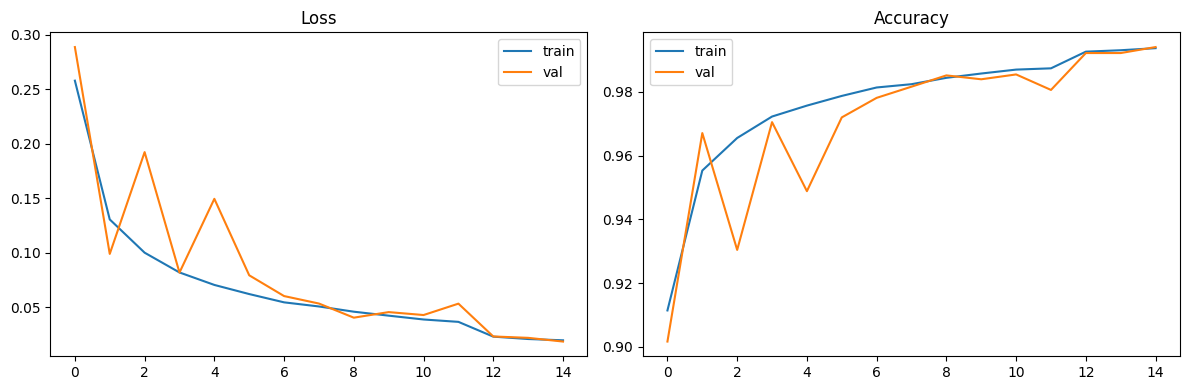

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'], label='val')
axes[0].set_title('Loss')
axes[0].legend()
axes[1].plot(history['train_acc'], label='train')
axes[1].plot(history['val_acc'], label='val')
axes[1].set_title('Accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()

## 8. Evaluation on test set

Проверяем целевые метрики из `PRD.md`: Accuracy ≥ 0.85 и F1 ≥ 0.80.

In [13]:
model.eval()
y_true, y_pred, y_conf = [], [], []
with torch.no_grad():
    for X, y in test_loader:
        X = X.to(DEVICE)
        probs = F.softmax(model(X), dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)
        y_true.extend(y.numpy())
        y_pred.extend(preds)
        y_conf.extend(probs.max(axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_conf = np.array(y_conf)

acc = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average='macro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

print(f'Accuracy:    {acc:.4f}  (target ≥ 0.85)')
print(f'F1 macro:    {f1_macro:.4f}  (target ≥ 0.80)')
print(f'F1 weighted: {f1_weighted:.4f}')
print(f'\nLow-confidence (<0.6) predictions: {(y_conf < 0.6).sum()} / {len(y_conf)}')
print('\nClassification report:')
print(classification_report(y_true, y_pred, target_names=list(CLASS_NAMES.values())))

Accuracy:    0.9755  (target ≥ 0.85)
F1 macro:    0.8816  (target ≥ 0.80)
F1 weighted: 0.9758

Low-confidence (<0.6) predictions: 132 / 21892

Classification report:
                  precision    recall  f1-score   support

          Normal       0.99      0.98      0.99     18118
Supraventricular       0.74      0.74      0.74       556
     Ventricular       0.94      0.95      0.94      1448
          Fusion       0.68      0.85      0.76       162
         Unknown       0.98      0.99      0.99      1608

        accuracy                           0.98     21892
       macro avg       0.86      0.90      0.88     21892
    weighted avg       0.98      0.98      0.98     21892



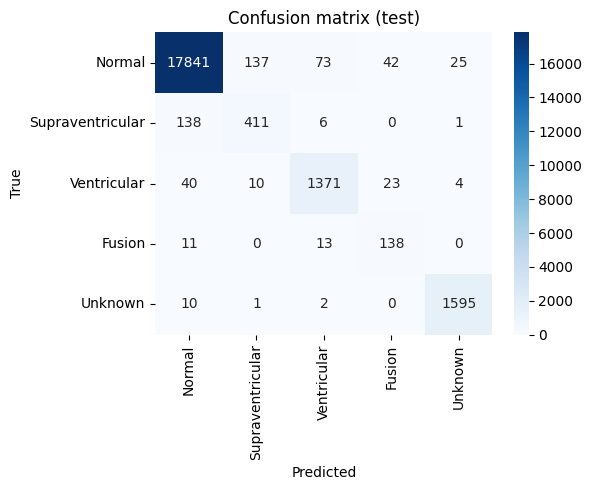

In [14]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(CLASS_NAMES.values()),
            yticklabels=list(CLASS_NAMES.values()))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion matrix (test)')
plt.tight_layout()
plt.show()

## 9. Сохранение модели

По `DoD.md` §2.6 сохраняем модель в формате `.pt`. Отдельно пиклим scaler и мету — нужны backend-у для inference.

In [15]:
ARTIFACTS_DIR = Path('../ml/artifacts')
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = ARTIFACTS_DIR / 'ecg_model.pt'
SCALER_PATH = ARTIFACTS_DIR / 'scaler.pkl'
META_PATH = ARTIFACTS_DIR / 'meta.pkl'

torch.save({
    'state_dict': model.state_dict(),
    'num_classes': NUM_CLASSES,
    'signal_len': SIGNAL_LEN,
    'arch': 'ECGNet-v1',
}, MODEL_PATH)

with open(SCALER_PATH, 'wb') as f:
    pickle.dump(scaler, f)

with open(META_PATH, 'wb') as f:
    pickle.dump({
        'class_names': CLASS_NAMES,
        'metrics': {'accuracy': acc, 'f1_macro': f1_macro, 'f1_weighted': f1_weighted},
        'low_conf_threshold': 0.6,
    }, f)

print(f'Saved model:  {MODEL_PATH}')
print(f'Saved scaler: {SCALER_PATH}')
print(f'Saved meta:   {META_PATH}')

Saved model:  ..\ml\artifacts\ecg_model.pt
Saved scaler: ..\ml\artifacts\scaler.pkl
Saved meta:   ..\ml\artifacts\meta.pkl


## 10. Inference function

Подходящая под API-контракт: на входе массив ~187 чисел, на выходе — класс и confidence. Low-confidence (<0.6) → fallback «не уверен».

In [16]:
def predict_signal(signal: list[float] | np.ndarray) -> dict:
    arr = np.array(signal, dtype=np.float32).reshape(1, -1)
    if arr.shape[1] != SIGNAL_LEN:
        raise ValueError(f'Ожидался сигнал длины {SIGNAL_LEN}, получено {arr.shape[1]}')

    arr = scaler.transform(arr)
    x = torch.tensor(arr, dtype=torch.float32).unsqueeze(1).to(DEVICE)

    model.eval()
    with torch.no_grad():
        probs = F.softmax(model(x), dim=1).cpu().numpy()[0]

    cls_id = int(probs.argmax())
    conf = float(probs[cls_id])
    label = CLASS_NAMES[cls_id] if conf >= 0.6 else 'не уверен'
    return {'class': label, 'class_id': cls_id, 'confidence': round(conf, 4)}


sample_idx = 0
demo_signal = X_test[sample_idx].tolist()
print(f'True class: {CLASS_NAMES[int(y_test[sample_idx])]}')
print(f'Prediction: {predict_signal(demo_signal)}')

True class: Normal
Prediction: {'class': 'Normal', 'class_id': 0, 'confidence': 1.0}
